In [1]:
import os
from pathlib import Path

PROJECT_DIR = Path(os.getenv('PROJECT_DIR'))
os.makedirs(PROJECT_DIR / 'paper/figures/subject_leakage', exist_ok=True)

In [2]:
import mlflow
client = mlflow.tracking.MlflowClient()

all_runs = mlflow.search_runs(search_all_experiments=True)

In [3]:
all_runs['subject_leakage'] = all_runs['params.data_leakage'].apply(lambda x: x == 'True')

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from itertools import combinations


def plot_grouped_boxplot_with_significance(
    df: pd.DataFrame,
    group_col: str,
    target_col: str,
    title: str = '',
    xlabel: str = '',
    ylabel: str = '',
    distinct_significance: bool = False,
    save_path: str | None = None,
    figsize: tuple[int, int] = (8, 4),
    invert_xaxis: bool = True,
    ax=None,
):
    # define significance level thresholds
    def get_star_annotation(p):
        if p < 0.05 and distinct_significance:
            if p < 0.001:
                return f'*** ({p=:.2e})'
            elif p < 0.01:
                return f'** ({p=:.2e})'
            else:
                return f'* ({p=:.2e})'
        elif p < 0.05:
            return f'* ({p=:.2e})'
            
        return ''
    
    # create the boxplot
    if figsize is not None:
        plt.figure(figsize=figsize)
    if ax is None:
        ax = sns.boxplot(x=group_col, y=target_col, data=df, hue=group_col)
    else:
        sns.boxplot(x=group_col, y=target_col, data=df, hue=group_col, ax=ax)
    
    # perform pairwise t-tests and collect significant pairs
    unique_groups = df[group_col].unique()
    y_max = df[target_col].max()
    y_offset = (df[target_col].max() - df[target_col].min()) * 0.15
    significance_annotations = []

    for i, (group1, group2) in enumerate(combinations(unique_groups, 2)):
        data1 = df[df[group_col] == group1][target_col]
        data2 = df[df[group_col] == group2][target_col]
        stat, p_val = ttest_ind(data1, data2, equal_var=False)

        stars = get_star_annotation(p_val)
        if stars:
            x1, x2 = unique_groups.tolist().index(group1), unique_groups.tolist().index(group2)
            y = y_max + y_offset * (len(significance_annotations) + 1)

            y_scale_param = 0.02
            ax.plot([x1, x1, x2, x2], [y, y+y_scale_param, y+y_scale_param, y], lw=1, c='black')
            ax.text((x1+x2)*.5, y+2*y_scale_param, stars, ha='center', va='bottom', color='black')
            
            significance_annotations.append((group1, group2, stars))

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if invert_xaxis:
        ax.invert_xaxis()
    sns.despine()
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
    return significance_annotations

### R-squared

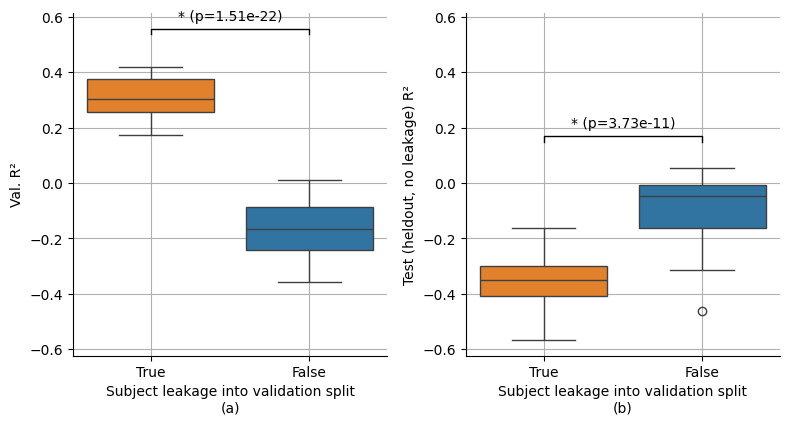

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True)
fig.set_figheight(4)
fig.set_figwidth(8)

label = 'Subject leakage into validation split'

# left plot
plot_grouped_boxplot_with_significance(
    all_runs,
    group_col='subject_leakage',
    target_col='metrics.val_r2_epoch',
    ylabel='Val. R²',
    figsize=None,
    ax=ax1
)

# right plot
plot_grouped_boxplot_with_significance(
    all_runs,
    group_col='subject_leakage',
    target_col='metrics.test_r2_epoch',
    ylabel='Test (heldout, no leakage) R²',
    figsize=None,
    ax=ax2
)

# customize left plot
ax1.grid()
ax1.get_legend().remove()
ax1.set_xlabel(f'{label}\n(a)')

# customize right plot
ax2.grid()
ax2.yaxis.get_label().set_visible(True)
ax2.yaxis.set_tick_params(labelleft=True)
ax2.get_legend().remove()
ax2.set_xlabel(f'{label}\n(b)')

plt.subplots_adjust(wspace=0.25)
plt.savefig(PROJECT_DIR / 'paper/figures/subject_leakage/00-r2.pdf', bbox_inches='tight')
plt.show()

In [6]:
label = 'r2'
caption = 'Impact of the subject leakage into validation split on $R^2$ metric.'

# aggregate results
agg = all_runs[['subject_leakage', 'metrics.val_r2_epoch', 'metrics.test_r2_epoch']].groupby('subject_leakage').aggregate(
    lambda x: f'${x.mean():.3f} \\pm {x.std():.3f}$'
)

# format tabular
latex = agg.to_latex()
latex = latex.replace(
    'subject_leakage',
    'Subject leakage into\nvalidation split'
).replace(
    'metrics.val_r2_epoch',
    'Val. $R^2$'
).replace(
    'metrics.test_r2_epoch',
    'Test (heldout, no leakage) $R^2$'
)

# format table
latex = f"""\
\\begin{{table}}
\\centering
\\caption{{{caption}}}
\\label{{tab:{label}}}
{latex}\\end{{table}}
"""
print(latex)

\begin{table}
\centering
\caption{Impact of the subject leakage into validation split on $R^2$ metric.}
\label{tab:r2}
\begin{tabular}{lll}
\toprule
 & Val. $R^2$ & Test (heldout, no leakage) $R^2$ \\
Subject leakage into
validation split &  &  \\
\midrule
False & $-0.166 \pm 0.100$ & $-0.090 \pm 0.119$ \\
True & $0.298 \pm 0.074$ & $-0.352 \pm 0.093$ \\
\bottomrule
\end{tabular}
\end{table}



### MAE

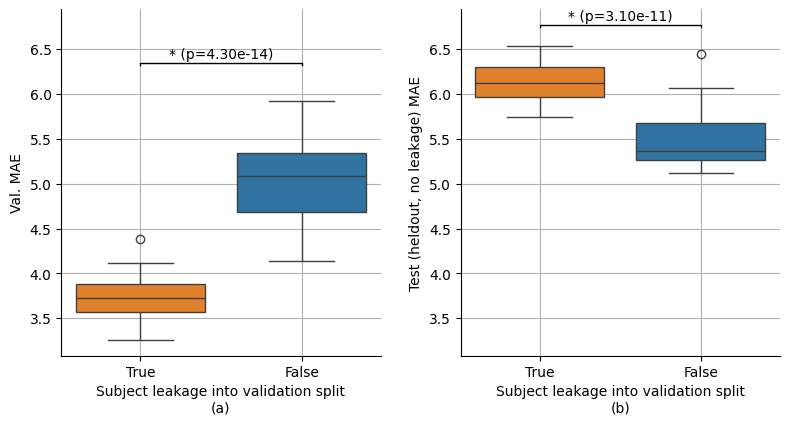

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True)
fig.set_figheight(4)
fig.set_figwidth(8)

label = 'Subject leakage into validation split'

# left plot
plot_grouped_boxplot_with_significance(
    all_runs,
    group_col='subject_leakage',
    target_col='metrics.val_mae_epoch',
    ylabel='Val. MAE',
    figsize=None,
    ax=ax1
)

# right plot
plot_grouped_boxplot_with_significance(
    all_runs,
    group_col='subject_leakage',
    target_col='metrics.test_mae_epoch',
    ylabel='Test (heldout, no leakage) MAE',
    figsize=None,
    ax=ax2
)

# customize left plot
ax1.grid()
ax1.get_legend().remove()
ax1.set_xlabel(f'{label}\n(a)')

# customize right plot
ax2.grid()
ax2.yaxis.get_label().set_visible(True)
ax2.yaxis.set_tick_params(labelleft=True)
ax2.get_legend().remove()
ax2.set_xlabel(f'{label}\n(b)')

plt.subplots_adjust(wspace=0.25)
plt.savefig(PROJECT_DIR / 'paper/figures/subject_leakage/01-mae.pdf', bbox_inches='tight')
plt.show()

In [8]:
label = 'mae'
caption = 'Impact of the subject leakage into validation split on MAE metric.'

# aggregate results
agg = all_runs[['subject_leakage', 'metrics.val_mae_epoch', 'metrics.test_mae_epoch']].groupby('subject_leakage').aggregate(
    lambda x: f'${x.mean():.3f} \\pm {x.std():.3f}$'
)

# format tabular
latex = agg.to_latex()
latex = latex.replace(
    'subject_leakage',
    'Subject leakage into\nvalidation split'
).replace(
    'metrics.val_mae_epoch',
    'Val. MAE'
).replace(
    'metrics.test_mae_epoch',
    'Test (heldout, no leakage) MAE'
)

# format table
latex = f"""\
\\begin{{table}}
\\centering
\\caption{{{caption}}}
\\label{{tab:{label}}}
{latex}\\end{{table}}
"""
print(latex)

\begin{table}
\centering
\caption{Impact of the subject leakage into validation split on MAE metric.}
\label{tab:mae}
\begin{tabular}{lll}
\toprule
 & Val. MAE & Test (heldout, no leakage) MAE \\
Subject leakage into
validation split &  &  \\
\midrule
False & $5.055 \pm 0.493$ & $5.478 \pm 0.308$ \\
True & $3.732 \pm 0.264$ & $6.142 \pm 0.212$ \\
\bottomrule
\end{tabular}
\end{table}

